#Find optimal number of PCs to explain 100% variance

In [39]:
def pc_count_full_variance():
    cum_var = np.cumsum(pca.explained_variance_ratio_ * 100)
    for threshold in [95, 98, 99.9, 99.99]:
        n_components = np.argmax(cum_var >= threshold) + 1
        print(
            f"{threshold}% variance -> {n_components} components "
            f"(actual={cum_var[n_components-1]:.3f}%)"
        )
    return n_components

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
df=pd.read_csv('./breast_cancer_data.csv')
print(df.shape)
df.drop(labels=['Unnamed: 32'],axis=1,inplace=True)
x=df.drop(labels=['diagnosis'],axis=1)
y=df['diagnosis']
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=10)
from sklearn.preprocessing import StandardScaler
s=StandardScaler()
x_trains=s.fit_transform(x_train)
x_tests=s.transform(x_test)
from sklearn.decomposition import PCA
pca=PCA(n_components=None)
x_trainp=pca.fit_transform(x_trains)
x_testp=pca.transform(x_tests)
n_pc=pc_count_full_variance()
print('n_pc:',n_pc)

from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
pca=PCA(n_components=n_pc+1)
x_trainp=pca.fit_transform(x_trains)
x_testp=pca.transform(x_tests)

knn=KNeighborsClassifier()
knn.fit(x_trainp,y_train)
y_pred=knn.predict(x_testp)
print('Accuracy score of KNN:',accuracy_score(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))
lr=LogisticRegression()
lr.fit(x_trainp,y_train)
y_pred=lr.predict(x_testp)
print('Accuracy score of Logistic Regression:',accuracy_score(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))
#print(classification_report(y_test,y_pred))
rfc=RandomForestClassifier(n_estimators=25)
rfc.fit(x_trainp,y_train)
y_pred=rfc.predict(x_testp)
print('Accuracy score of RandomForestClassifier:',accuracy_score(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))

(569, 33)
95% variance -> 11 components (actual=95.651%)
98% variance -> 15 components (actual=98.391%)
99.9% variance -> 25 components (actual=99.910%)
99.99% variance -> 28 components (actual=99.992%)
n_pc: 28
Accuracy score of KNN: 0.9912280701754386
[[75  0]
 [ 1 38]]
Accuracy score of Logistic Regression: 0.9649122807017544
[[73  2]
 [ 2 37]]
Accuracy score of RandomForestClassifier: 0.9736842105263158
[[73  2]
 [ 1 38]]


In [16]:
import numpy as np
import pandas as pd
import plotly.express as px
import matplotlib.pyplot as plt
df=pd.read_csv('./dr_train.csv')
x=df.iloc[:,1:]
y=df.iloc[:,0]
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)
from sklearn.preprocessing import StandardScaler
s=StandardScaler()
x_trains=s.fit_transform(x_train)
x_tests=s.transform(x_test)
from sklearn.decomposition import PCA

pca = PCA(n_components=None)
x_train = pca.fit_transform(x_trains)
x_test = pca.transform(x_tests)
cum_var = np.cumsum(pca.explained_variance_ratio_ * 100)
for threshold in [95, 98, 99.9, 99.99]:
    n_components = np.argmax(cum_var >= threshold) + 1
    print(
        f"{threshold}% variance -> {n_components} components "
        f"(actual={cum_var[n_components-1]:.3f}%)"
    )

95% variance -> 315 components (actual=95.029%)
98% variance -> 443 components (actual=98.001%)
99.9% variance -> 666 components (actual=99.902%)
99.99% variance -> 692 components (actual=99.992%)


#Use that PC count in the ML algorithm

In [4]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
pca=PCA(n_components=694)
x_train_pca=pca.fit_transform(x_trains)
x_test_pca=pca.transform(x_tests)
knn=KNeighborsClassifier()
knn.fit(x_train_pca,y_train)
y_pred=knn.predict(x_test_pca)
print(accuracy_score(y_test,y_pred))
cm=confusion_matrix(y_test,y_pred)
print(cm)
print(classification_report(y_test,y_pred))

0.9391666666666667
[[802   0   3   0   0   1  10   0   0   0]
 [  0 903   2   0   0   1   2   0   1   0]
 [ 10  12 787  12   2   3   5   4   8   3]
 [  4   4   2 883   0  16   1   9   9   9]
 [  2   6   5   2 788   2   4   3   0  27]
 [  4   1   3  26   2 645  12   1   3   5]
 [ 12   1   3   0   1   8 760   0   0   0]
 [  2  17   6   6  11   0   0 823   0  28]
 [  6  14   7  19  13  35   5   2 729   5]
 [  6   3   3  13  10   1   0  29   4 769]]
              precision    recall  f1-score   support

           0       0.95      0.98      0.96       816
           1       0.94      0.99      0.97       909
           2       0.96      0.93      0.94       846
           3       0.92      0.94      0.93       937
           4       0.95      0.94      0.95       839
           5       0.91      0.92      0.91       702
           6       0.95      0.97      0.96       785
           7       0.94      0.92      0.93       893
           8       0.97      0.87      0.92       835
         

In [123]:
import pandas as pd
import plotly.express as px
import matplotlib.pyplot as plt
import numpy as np

df=pd.read_csv('.\dr_train.csv')
df1=pd.read_csv('.\dr_test.csv')
df1.shape

(28000, 784)

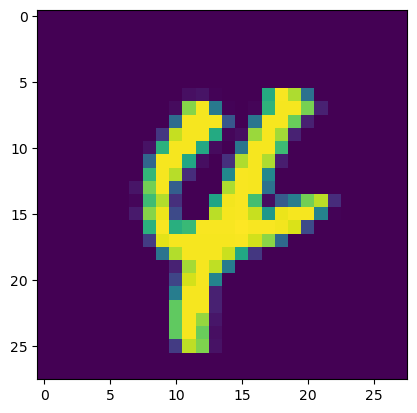

In [2]:
plt.imshow(df.iloc[19707,1:].values.reshape(28,28));

In [124]:
x=df.iloc[:,1:]
y=df.iloc[:,0]
x.shape,y.shape

((42000, 784), (42000,))

In [125]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)
x_train.shape, x_test.shape

((33600, 784), (8400, 784))

In [126]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
knn=KNeighborsClassifier()
import time
s=time.time()
knn.fit(x_train,y_train)
print(time.time()-s)

0.2648646831512451


In [127]:
s=time.time()
y_pred=knn.predict(x_test)
print(time.time()-s)
print(accuracy_score(y_test,y_pred))

16.487889051437378
0.9648809523809524


In [128]:
from sklearn.metrics import confusion_matrix,classification_report
cm=confusion_matrix(y_test,y_pred)
print(cm)
print(classification_report(y_test,y_pred))

[[812   0   0   0   0   0   4   0   0   0]
 [  0 906   0   0   0   0   3   0   0   0]
 [  6  15 796   3   2   2   1  20   1   0]
 [  2   4   4 900   0   9   1   6   5   6]
 [  1   5   0   0 811   0   3   1   0  18]
 [  1   2   0  15   1 669   9   0   1   4]
 [  5   0   0   0   0   3 777   0   0   0]
 [  0  18   2   0   1   0   0 857   0  15]
 [  1  12   2  12   3  15   4   1 777   8]
 [  3   3   1  10   6   1   0  12   2 800]]
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       816
           1       0.94      1.00      0.97       909
           2       0.99      0.94      0.96       846
           3       0.96      0.96      0.96       937
           4       0.98      0.97      0.98       839
           5       0.96      0.95      0.96       702
           6       0.97      0.99      0.98       785
           7       0.96      0.96      0.96       893
           8       0.99      0.93      0.96       835
           9       0.94     

In [8]:
from sklearn.preprocessing import StandardScaler
s=StandardScaler()
x_trains=s.fit_transform(x_train)
x_tests=s.transform(x_test)

In [114]:
from sklearn.decomposition import PCA
pca=PCA(n_components=None)
x_train_pca=pca.fit_transform(x_trains)
x_test_pca=pca.transform(x_tests)
x_train_pca.shape

(33600, 784)

In [119]:
knn=KNeighborsClassifier()
knn.fit(x_train_pca,y_train)
y_pred=knn.predict(x_test_pca)
print(accuracy_score(y_test,y_pred))
from sklearn.metrics import confusion_matrix,classification_report
cm=confusion_matrix(y_test,y_pred)
print(cm)
print(classification_report(y_test,y_pred))

0.9391666666666667
[[802   0   3   0   0   1  10   0   0   0]
 [  0 903   2   0   0   1   2   0   1   0]
 [ 10  12 787  12   2   3   5   4   8   3]
 [  4   4   2 883   0  16   1   9   9   9]
 [  2   6   5   2 788   2   4   3   0  27]
 [  4   1   3  26   2 645  12   1   3   5]
 [ 12   1   3   0   1   8 760   0   0   0]
 [  2  17   6   6  11   0   0 823   0  28]
 [  6  14   7  19  13  35   5   2 729   5]
 [  6   3   3  13  10   1   0  29   4 769]]
              precision    recall  f1-score   support

           0       0.95      0.98      0.96       816
           1       0.94      0.99      0.97       909
           2       0.96      0.93      0.94       846
           3       0.92      0.94      0.93       937
           4       0.95      0.94      0.95       839
           5       0.91      0.92      0.91       702
           6       0.95      0.97      0.96       785
           7       0.94      0.92      0.93       893
           8       0.97      0.87      0.92       835
         

In [84]:
for i in range(1,6):
    pca=PCA(n_components=i)
    x_train=pca.fit_transform(x_trains)
    x_test=pca.transform(x_tests)
    knn=KNeighborsClassifier()
    knn.fit(x_train,y_train)
    y_pred=knn.predict(x_test)
    print(i,accuracy_score(y_test,y_pred))

1 0.2580952380952381
2 0.3236904761904762
3 0.5104761904761905
4 0.6663095238095238
5 0.7378571428571429


In [85]:
pca = PCA(n_components=None)
x_train = pca.fit_transform(x_trains)
x_test = pca.transform(x_tests)

In [102]:
#print(f"{pca.explained_variance_.item():.2f}")
j=0
s=0
for i in pca.explained_variance_ratio_*100:
    j+=1
    s+=round(i,3)
    if s in(80,90,95,98,99.9):
        print(j,f"{i:.3f},",round(s,2))
#pca.explained_variance_.shape,pca.components_.shape,pca.explained_variance_ratio_.shape

In [131]:
import numpy as np
import pandas as pd
import plotly.express as px
import matplotlib.pyplot as plt
df=pd.read_csv('.\dr_train.csv')
x=df.iloc[:,1:]
y=df.iloc[:,0]
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)
from sklearn.preprocessing import StandardScaler
s=StandardScaler()
x_trains=s.fit_transform(x_train)
x_tests=s.transform(x_test)
pca = PCA(n_components=None)
x_train = pca.fit_transform(x_trains)
x_test = pca.transform(x_tests)
cum_var = np.cumsum(pca.explained_variance_ratio_ * 100)
for threshold in [95, 98, 99.9, 99.99]:
    n_components = np.argmax(cum_var >= threshold) + 1
    print(
        f"{threshold}% variance -> {n_components} components "
        f"(actual={cum_var[n_components-1]:.3f}%)"
    )

95% variance -> 315 components (actual=95.029%)
98% variance -> 443 components (actual=98.001%)
99.9% variance -> 666 components (actual=99.902%)
99.99% variance -> 692 components (actual=99.992%)


In [132]:
from sklearn.decomposition import PCA
pca=PCA(n_components=694)
x_train_pca=pca.fit_transform(x_trains)
x_test_pca=pca.transform(x_tests)
knn=KNeighborsClassifier()
knn.fit(x_train_pca,y_train)
y_pred=knn.predict(x_test_pca)
print(accuracy_score(y_test,y_pred))
from sklearn.metrics import confusion_matrix,classification_report
cm=confusion_matrix(y_test,y_pred)
print(cm)
print(classification_report(y_test,y_pred))

0.9391666666666667
[[802   0   3   0   0   1  10   0   0   0]
 [  0 903   2   0   0   1   2   0   1   0]
 [ 10  12 787  12   2   3   5   4   8   3]
 [  4   4   2 883   0  16   1   9   9   9]
 [  2   6   5   2 788   2   4   3   0  27]
 [  4   1   3  26   2 645  12   1   3   5]
 [ 12   1   3   0   1   8 760   0   0   0]
 [  2  17   6   6  11   0   0 823   0  28]
 [  6  14   7  19  13  35   5   2 729   5]
 [  6   3   3  13  10   1   0  29   4 769]]
              precision    recall  f1-score   support

           0       0.95      0.98      0.96       816
           1       0.94      0.99      0.97       909
           2       0.96      0.93      0.94       846
           3       0.92      0.94      0.93       937
           4       0.95      0.94      0.95       839
           5       0.91      0.92      0.91       702
           6       0.95      0.97      0.96       785
           7       0.94      0.92      0.93       893
           8       0.97      0.87      0.92       835
         

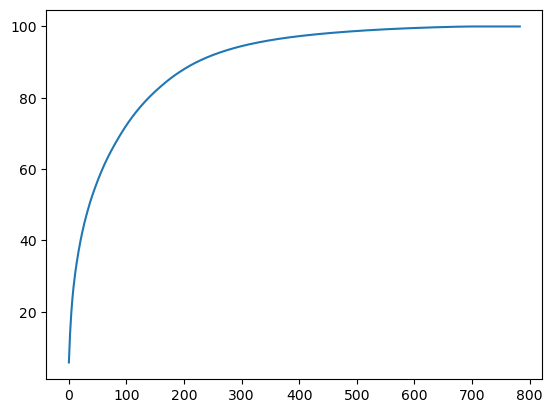

In [82]:
plt.plot(np.cumsum(pca.explained_variance_ratio_*100));